# Modelo predictivo: Predicción de Churn en una Telco

### **Restricción de negocio (IMPORTANTE)**
La empresa solo puede contactar a 2000 de los clientes cada mes debido a
limitaciones operativas. <br>
Cada contacto tiene un costo de $1000 CLP por cliente. <br>
Adicionalmente, se asume que:

*   El valor total recuperado por un cliente retenido es de $30.000 CLP
*   La tasa de éxito de retención de la campaña es de solo el 10% sobre los que
efectivamente habrían hecho churn. <br>

Para esta sección, utiliza estos supuestos de negocio para tu análisis y toma de
decisiones

### **0. Carga librerias y Carga de Train y Test**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, make_scorer
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Configuración de visualización
%matplotlib inline
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Cargar datos ────────────────────
import pandas as pd

df_train = pd.read_csv('train_modelo.csv')
df_test  = pd.read_csv('test_modelo.csv')

FEATURES = [c for c in df_train.columns
            if c not in ['churn', 'mobile_number']]

X_train   = df_train[FEATURES]
y_train   = df_train['churn']
idx_train = df_train['mobile_number'].values

X_test    = df_test[FEATURES]
y_test    = df_test['churn']
idx_test  = df_test['mobile_number'].values

print(f"X_train : {X_train.shape} | churn: {y_train.mean():.4f}")
print(f"X_test  : {X_test.shape}  | churn: {y_test.mean():.4f}")

X_train : (199397, 69) | churn: 0.0128
X_test  : (98899, 69)  | churn: 0.0190


In [2]:
# ── Verificación final antes del modelo ───────────────────────────────────

# 1. Tipos de datos
tipos = X_train.dtypes
no_numericas = tipos[~tipos.isin([
    'int64','float64','int32','float32','int8','uint8','bool'
])]
print(f"Columnas no numéricas: {list(no_numericas.index) if len(no_numericas) > 0 else 'Ninguna ✓'}")

# 2. Booleanos pendientes
bool_cols = X_train.select_dtypes(include='bool').columns.tolist()
print(f"Columnas booleanas   : {bool_cols if bool_cols else 'Ninguna ✓'}")
if bool_cols:
    X_train[bool_cols] = X_train[bool_cols].astype(int)
    X_test[bool_cols]  = X_test[bool_cols].astype(int)
    print(f"  → Convertidas a int ✓")

# 3. Nulos
nulos_train = X_train.isnull().sum()
nulos_train = nulos_train[nulos_train > 0].sort_values(ascending=False)
print(f"\nNulos en X_train ({len(nulos_train)} columnas):")
print(nulos_train.head(10) if len(nulos_train) > 0 else "  Ninguno ✓")

nulos_test = X_test.isnull().sum()
nulos_test = nulos_test[nulos_test > 0].sort_values(ascending=False)
print(f"\nNulos en X_test ({len(nulos_test)} columnas):")
print(nulos_test.head(10) if len(nulos_test) > 0 else "  Ninguno ✓")

# 4. Resumen
print(f"\n{'─'*40}")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Features: {len(FEATURES)}")
print(f"Churn rate train: {y_train.mean():.4f}")
print(f"Churn rate test : {y_test.mean():.4f}")

Columnas no numéricas: ['arpu', 'onnet_mou', 'offnet_mou', 'roam_ic_mou', 'roam_og_mou', 'loc_og_t2t_mou', 'loc_og_t2m_mou', 'loc_og_t2f_mou', 'loc_og_t2c_mou', 'loc_og_mou', 'std_og_t2t_mou', 'std_og_t2m_mou', 'std_og_t2f_mou', 'std_og_mou', 'isd_og_mou', 'spl_og_mou', 'og_others', 'total_og_mou', 'loc_ic_t2t_mou', 'loc_ic_t2m_mou', 'loc_ic_t2f_mou', 'loc_ic_mou', 'std_ic_t2t_mou', 'std_ic_t2m_mou', 'std_ic_t2f_mou', 'std_ic_mou', 'total_ic_mou', 'spl_ic_mou', 'isd_ic_mou', 'ic_others', 'total_rech_num', 'total_rech_amt', 'max_rech_amt', 'last_day_rch_amt', 'total_rech_data', 'max_rech_data', 'count_rech_2g', 'count_rech_3g', 'av_rech_amt_data', 'vol_2g_mb', 'vol_3g_mb', 'arpu_3g', 'arpu_2g', 'night_pck_user', 'sachet_2g', 'sachet_3g', 'recency_dias', 'Cluster_RFM', 'monthly_2g_1', 'monthly_2g_2', 'monthly_2g_3', 'monthly_2g_4', 'monthly_2g_5', 'monthly_3g_1', 'monthly_3g_2', 'monthly_3g_3', 'monthly_3g_4', 'monthly_3g_5', 'monthly_3g_6', 'monthly_3g_7', 'monthly_3g_8', 'monthly_3g_9'

In [3]:
print("Tipos en X_train:")
print(X_train.dtypes.value_counts())
print()
print(f"¿Algún tipo object o datetime?: "
      f"{'Sí ⚠' if X_train.select_dtypes(include=['object','datetime64']).shape[1] > 0 else 'No ✓'}")
print()
print(f"Nulos en X_train: {X_train.isnull().sum().sum():,}")
print(f"Nulos en X_test : {X_test.isnull().sum().sum():,}")

Tipos en X_train:
float64    41
int64      28
Name: count, dtype: int64

¿Algún tipo object o datetime?: No ✓

Nulos en X_train: 0
Nulos en X_test : 0


Se cargó los datos de train y test resultantes del analisis EDA. <br>
Adicionalmente, se validaron los datos para que coincidan con lo validado en el archivo anterior.

### **1. Modelamiento baseline y prueba de ratios de desbalanceo**

### 1. Modelamiento baseline y prueba de ratios de desbalanceo

Para este punto se utilizará el ratio de 1:77 como punto de referencia
para definir el límite de ratios a probar.
Dado esto, se probaron ratios iniciando en 1.0 y terminando en 0.02,
justo antes del límite natural del dataset.

Este proceso es fundamental cuando se trabaja con datasets con
desbalance extremo como el presente (1.28% de churn). Dado que entrenarlo directamente es un camino seguro al overfitting por la clase mayoritaria excesiva.

Mediante este proceso podemos:

1. **Controlar el trade-off Recall/Precision:** ratios altos generan
   modelos más agresivos (alto recall, baja precision) mientras que
   ratios bajos generan modelos más conservadores (baja recall,
   alta precision).

2. **Simular distintos escenarios de campaña:** cada ratio representa
   una estrategia distinta de contactabilidad. Un ratio alto captura
   más churners pero con más falsos positivos; un ratio bajo es más
   selectivo pero se pierde churners reales. <br> 
   Esto es importante debido a las restricciones de negocio mencionadas previmanete y que posteriormente se explicará.

3. **Hacer una prueba de estrés del modelo:** comparar las métricas
   en el set balanceado (train) vs el set real (test con ratio 1:77)
   permite medir cuánto generaliza el modelo fuera de la burbuja
   de entrenamiento. Una caída de F1 (balance entre presición y recall) pequeña indica mejor
   generalización.

In [ ]:
print(f"Shape Train filtrado: {X_train.shape}")

# ── 2. Experimento de Ratios (Prueba de Estrés Train vs Test) ─────────────
# 1.0 (1:1), 0.5 (1:2), 0.25 (1:4), 0.15 (~1:6), 0.10 (1:10), 0.05 (1:20), 0.014 (~1:70)
ratios_a_probar = [1.0, 0.5, 0.25, 0.15, 0.10, 0.05, 0.02]

print("\n" + "═"*60)
print("  EXPERIMENTO DE RATIOS (Prueba de Estrés Train vs Test Real)")
print("═"*60)

for ratio in ratios_a_probar:
    print(f"\n[ Entrenando con Ratio Minoritaria/Mayoritaria = {ratio} ]")

    # 1. Aplicar Undersampling SOLO AL TRAIN
    rus = RandomUnderSampler(sampling_strategy=ratio, random_state=42)
    X_res, y_res = rus.fit_resample(X_train, y_train)

    # 2. Entrenar modelo
    modelo_exp = xgb.XGBClassifier(
        n_estimators=150,
        max_depth=5,
        learning_rate=0.05,
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    )
    modelo_exp.fit(X_res, y_res)

    # 3. MÉTRICAS EN TRAIN (La burbuja balanceada)
    y_pred_train = modelo_exp.predict(X_res)
    y_prob_train = modelo_exp.predict_proba(X_res)[:, 1]

    auc_train = roc_auc_score(y_res, y_prob_train)
    f1_train  = f1_score(y_res, y_pred_train)
    rec_train = recall_score(y_res, y_pred_train)
    prec_train = precision_score(y_res, y_pred_train)

    # 4. MÉTRICAS EN TEST (El mundo real ~ 1:77)
    y_pred_test = modelo_exp.predict(X_test)
    y_prob_test = modelo_exp.predict_proba(X_test)[:, 1]

    auc_test = roc_auc_score(y_test, y_prob_test)
    f1_test  = f1_score(y_test, y_pred_test)
    rec_test = recall_score(y_test, y_pred_test)
    prec_test = precision_score(y_test, y_pred_test)

    # 5. IMPRIMIR COMPARACIÓN
    print(f"  > MÉTRICAS TRAIN (Ratio {ratio}):")
    print(f"      ROC-AUC: {auc_train:.4f} | F1: {f1_train:.4f} | Recall: {rec_train:.4f} | Precision: {prec_train:.4f}")

    print(f"  > MÉTRICAS TEST  (Real 1:77):")
    print(f"      ROC-AUC: {auc_test:.4f} | F1: {f1_test:.4f} | Recall: {rec_test:.4f} | Precision: {prec_test:.4f}")

    # Medir la caída del F1-Score
    caida_f1 = (f1_train - f1_test) * 100
    print(f"      ⚠️ Caída del F1-Score al pasar al mundo real: {caida_f1:.1f} puntos")

Shape Train filtrado (Solo Julio): (199397, 69)

════════════════════════════════════════════════════════════
  EXPERIMENTO DE RATIOS (Prueba de Estrés Train vs Test Real)
════════════════════════════════════════════════════════════

[ Entrenando con Ratio Minoritaria/Mayoritaria = 1.0 ]
  > MÉTRICAS TRAIN (Ratio 1.0):
      ROC-AUC: 0.9691 | F1: 0.9107 | Recall: 0.9000 | Precision: 0.9217
  > MÉTRICAS TEST  (Real 1:77):
      ROC-AUC: 0.9296 | F1: 0.1924 | Recall: 0.8560 | Precision: 0.1084
      ⚠️ Caída del F1-Score al pasar al mundo real: 71.8 puntos

[ Entrenando con Ratio Minoritaria/Mayoritaria = 0.5 ]
  > MÉTRICAS TRAIN (Ratio 0.5):
      ROC-AUC: 0.9662 | F1: 0.8500 | Recall: 0.8165 | Precision: 0.8864
  > MÉTRICAS TEST  (Real 1:77):
      ROC-AUC: 0.9293 | F1: 0.2628 | Recall: 0.8130 | Precision: 0.1568
      ⚠️ Caída del F1-Score al pasar al mundo real: 58.7 puntos

[ Entrenando con Ratio Minoritaria/Mayoritaria = 0.25 ]
  > MÉTRICAS TRAIN (Ratio 0.25):
      ROC-AUC: 0.9612

In [ ]:
# ── 1. Preparación Segura para Random Forest (Cero NaNs) ─────────────────
# Llenamos cualquier posible NaN restante con 0
X_train_rf = X_train.fillna(0).copy()
X_test_rf  = X_test.fillna(0).copy()

# ── 2. Experimento de Ratios con Random Forest ────────────────────────────
ratios_a_probar = [1.0, 0.5, 0.25, 0.15, 0.10, 0.05, 0.02]

print("\n" + "═"*60)
print("  EXPERIMENTO DE RATIOS (Random Forest vs Test Real)")
print("═"*60)

for ratio in ratios_a_probar:
    print(f"\n[ Entrenando con Ratio Minoritaria/Mayoritaria = {ratio} ]")

    # 1. Aplicar Undersampling SOLO AL TRAIN de Julio
    rus = RandomUnderSampler(sampling_strategy=ratio, random_state=42)
    X_res, y_res = rus.fit_resample(X_train_rf, y_train)

    # 2. Entrenar Random Forest
    # Usamos max_depth=20 como en tu baseline.
    # Quitamos class_weight porque rus ya hace el balanceo.
    modelo_rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    modelo_rf.fit(X_res, y_res)

    # 3. MÉTRICAS EN TRAIN (La burbuja balanceada)
    y_pred_train = modelo_rf.predict(X_res)
    y_prob_train = modelo_rf.predict_proba(X_res)[:, 1]

    auc_train = roc_auc_score(y_res, y_prob_train)
    f1_train  = f1_score(y_res, y_pred_train)
    rec_train = recall_score(y_res, y_pred_train)
    prec_train = precision_score(y_res, y_pred_train)

    # 4. MÉTRICAS EN TEST (El mundo real ~ 1:77)
    y_pred_test = modelo_rf.predict(X_test_rf)
    y_prob_test = modelo_rf.predict_proba(X_test_rf)[:, 1]

    auc_test = roc_auc_score(y_test, y_prob_test)
    f1_test  = f1_score(y_test, y_pred_test)
    rec_test = recall_score(y_test, y_pred_test)
    prec_test = precision_score(y_test, y_pred_test)

    # 5. IMPRIMIR COMPARACIÓN
    print(f"  > MÉTRICAS TRAIN (Ratio {ratio}):")
    print(f"      ROC-AUC: {auc_train:.4f} | F1: {f1_train:.4f} | Recall: {rec_train:.4f} | Precision: {prec_train:.4f}")

    print(f"  > MÉTRICAS TEST  (Real 1:77):")
    print(f"      ROC-AUC: {auc_test:.4f} | F1: {f1_test:.4f} | Recall: {rec_test:.4f} | Precision: {prec_test:.4f}")

    # Medir la caída del F1-Score
    caida_f1 = (f1_train - f1_test) * 100
    print(f"      ⚠️ Caída del F1-Score al pasar al mundo real: {caida_f1:.1f} puntos")


════════════════════════════════════════════════════════════
  EXPERIMENTO DE RATIOS (Random Forest vs Test Real)
════════════════════════════════════════════════════════════

[ Entrenando con Ratio Minoritaria/Mayoritaria = 1.0 ]
  > MÉTRICAS TRAIN (Ratio 1.0):
      ROC-AUC: 0.9730 | F1: 0.9159 | Recall: 0.8855 | Precision: 0.9484
  > MÉTRICAS TEST  (Real 1:77):
      ROC-AUC: 0.9259 | F1: 0.2123 | Recall: 0.8385 | Precision: 0.1215
      ⚠️ Caída del F1-Score al pasar al mundo real: 70.4 puntos

[ Entrenando con Ratio Minoritaria/Mayoritaria = 0.5 ]
  > MÉTRICAS TRAIN (Ratio 0.5):
      ROC-AUC: 0.9717 | F1: 0.8458 | Recall: 0.7805 | Precision: 0.9230
  > MÉTRICAS TEST  (Real 1:77):
      ROC-AUC: 0.9271 | F1: 0.2986 | Recall: 0.7683 | Precision: 0.1853
      ⚠️ Caída del F1-Score al pasar al mundo real: 54.7 puntos

[ Entrenando con Ratio Minoritaria/Mayoritaria = 0.25 ]
  > MÉTRICAS TRAIN (Ratio 0.25):
      ROC-AUC: 0.9677 | F1: 0.7673 | Recall: 0.6923 | Precision: 0.8606
  > MÉ

In [ ]:
# ── GBM con experimento de ratios ─────────────────────────────────────────
print("═" * 60)
print("  EXPERIMENTO DE RATIOS — GBM (sklearn)")
print("═" * 60)
# ── 1. Preparación Segura para Random Forest (Cero NaNs) ─────────────────
# Llenamos cualquier posible NaN restante con 0
X_train_gbm = X_train.fillna(0).copy()
X_test_gbm  = X_test.fillna(0).copy()

ratios_a_probar = [1.0, 0.5, 0.25, 0.15, 0.10, 0.05, 0.02]

for ratio in ratios_a_probar:
    print(f"\n[ Ratio = {ratio} ]")

    rus = RandomUnderSampler(sampling_strategy=ratio, random_state=42)
    X_r, y_r = rus.fit_resample(X_train_gbm, y_train)

    gbm = GradientBoostingClassifier(
        n_estimators  = 150,
        max_depth     = 5,
        learning_rate = 0.05,
        subsample     = 0.8,
        random_state  = 42
    )
    gbm.fit(X_r, y_r)

    # Train
    y_pred_train = gbm.predict(X_r)
    y_prob_train = gbm.predict_proba(X_r)[:, 1]
    auc_train    = roc_auc_score(y_r, y_prob_train)
    f1_train     = f1_score(y_r, y_pred_train)
    rec_train    = recall_score(y_r, y_pred_train)
    prec_train   = precision_score(y_r, y_pred_train)

    # Test
    y_pred_test = gbm.predict(X_test_gbm)
    y_prob_test = gbm.predict_proba(X_test_gbm)[:, 1]
    auc_test    = roc_auc_score(y_test, y_prob_test)
    f1_test     = f1_score(y_test, y_pred_test)
    rec_test    = recall_score(y_test, y_pred_test)
    prec_test   = precision_score(y_test, y_pred_test)

    caida = (f1_train - f1_test) * 100

    print(f"  > TRAIN: AUC={auc_train:.4f} | F1={f1_train:.4f} | "
          f"Rec={rec_train:.4f} | Prec={prec_train:.4f}")
    print(f"  > TEST : AUC={auc_test:.4f} | F1={f1_test:.4f} | "
          f"Rec={rec_test:.4f} | Prec={prec_test:.4f}")
    print(f"  ⚠ Caída F1: {caida:.1f} puntos")

════════════════════════════════════════════════════════════
  EXPERIMENTO DE RATIOS — GBM (sklearn)
════════════════════════════════════════════════════════════

[ Ratio = 1.0 ]
  > TRAIN: AUC=0.9755 | F1=0.9265 | Rec=0.9196 | Prec=0.9335
  > TEST : AUC=0.9305 | F1=0.1952 | Rec=0.8661 | Prec=0.1100
  ⚠ Caída F1: 73.1 puntos

[ Ratio = 0.5 ]
  > TRAIN: AUC=0.9713 | F1=0.8641 | Rec=0.8303 | Prec=0.9009
  > TEST : AUC=0.9313 | F1=0.2610 | Rec=0.8082 | Prec=0.1556
  ⚠ Caída F1: 60.3 puntos

[ Ratio = 0.25 ]
  > TRAIN: AUC=0.9660 | F1=0.7953 | Rec=0.7483 | Prec=0.8484
  > TEST : AUC=0.9295 | F1=0.3263 | Rec=0.7194 | Prec=0.2110
  ⚠ Caída F1: 46.9 puntos

[ Ratio = 0.15 ]
  > TRAIN: AUC=0.9643 | F1=0.7395 | Rec=0.6837 | Prec=0.8052
  > TEST : AUC=0.9282 | F1=0.3666 | Rec=0.6674 | Prec=0.2527
  ⚠ Caída F1: 37.3 puntos

[ Ratio = 0.1 ]
  > TRAIN: AUC=0.9642 | F1=0.6943 | Rec=0.6441 | Prec=0.7530
  > TEST : AUC=0.9267 | F1=0.3808 | Rec=0.6079 | Prec=0.2772
  ⚠ Caída F1: 31.4 puntos

[ Ratio = 

**Selección de ratio óptimo por modelo**

Tras evaluar 7 ratios de desbalanceo (1.0, 0.5, 0.25, 0.15, 0.10, 0.05, 0.02)
para cada modelo, se seleccionó el **ratio 0.10** como óptimo para los
3 modelos evaluados.

**¿Por qué ratio 0.10 en los 3 modelos?**

El ratio 0.10 representa entrenar con 1 churner por cada
10 no-churners, lo que equivale a un desbalance artificial
de 1:10 vs el real de 1:77.

Este punto resultó óptimo porque:

- **Ratios más altos (1.0, 0.5, 0.25):** el modelo ve demasiados
  churners durante el entrenamiento. Aprende bien la clase minoritaria
  pero cuando se enfrenta al ratio real (1:77) sus métricas como F1 score caen bruscamente. <br> Podria deberse al undersampling especialmente en ratios mas grandes.

- **Ratios más bajos (0.05, 0.02):** El modelo empieza a ver tan pocos casos de churn en el train y se vuelve conversador es decir no aprende suficientemente los patrones de la clase minoritaria y sube la precision a costa de un recall muy bajo.

- **Ratio 0.10:** punto de equilibrio donde la caída de F1 entre
  train y test es menor (27-31 puntos vs 70+ puntos en ratios altos),
  lo que indica mejor generalización.

Este ratio se usó como base para la prueba de ensamble de modelos y el tuning posterior,
manteniendo consistencia en la estrategia de balanceo entre los 3 modelos.

### 2. Prueba de ensamble de modelos por combinación

Dado que los 3 modelos baseline (XGBoost, Random Forest y GBM)
fueron entrenados con el mismo ratio 0.10 y obtuvieron métricas
similares en test, se evaluó la posibilidad de combinarlos.

La idea detrás del ensamble es que cada modelo puede capturar
patrones distintos en los datos. Al promediar sus probabilidades
de churn, se esperaba obtener un ranking más robusto que
cualquier modelo individual, reduciendo el error de cada uno.

Se probaron 7 combinaciones:

- Modelos individuales como referencia (XGB, RF, GBM)
- Ensambles de 2 modelos (XGB+RF, XGB+GBM, RF+GBM)
- Ensamble de los 3 modelos (XGB+RF+GBM)
- Ensamble ponderado dando más peso a XGB y RF

In [ ]:
# Ensamble: Voting por promedio de probabilidades
# Usar el mejor ratio de cada modelo según resultados de hoy:
# XGB → ratio 0.10  (F1=0.392, mejor balance)
# RF  → ratio 0.10  (F1=0.411, mejor F1)
# GBM → ratio 0.10  (F1=0.381, mejor balance)

print("Entrenando modelos para el ensamble...")
print("─" * 45)

# ── XGBoost ───────────────────────────────────────────────────────────────
rus_xgb = RandomUnderSampler(sampling_strategy=0.10, random_state=42)
X_r_xgb, y_r_xgb = rus_xgb.fit_resample(X_train, y_train)

xgb_ens = xgb.XGBClassifier(
    n_estimators=150, max_depth=5, learning_rate=0.05,
    tree_method='hist', random_state=42, n_jobs=-1
)
xgb_ens.fit(X_r_xgb, y_r_xgb)
prob_xgb = xgb_ens.predict_proba(X_test)[:, 1]
print(f"XGB entrenado ✓  AUC={roc_auc_score(y_test, prob_xgb):.4f}")

# ── Random Forest ─────────────────────────────────────────────────────────

rus_rf = RandomUnderSampler(sampling_strategy=0.10, random_state=42)
X_r_rf, y_r_rf = rus_rf.fit_resample(X_train, y_train)

rf_ens = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    n_jobs=-1, random_state=42
)
rf_ens.fit(X_r_rf, y_r_rf)
prob_rf = rf_ens.predict_proba(X_test)[:, 1]
print(f"RF  entrenado ✓  AUC={roc_auc_score(y_test, prob_rf):.4f}")

# ── GBM ───────────────────────────────────────────────────────────────────

rus_gbm = RandomUnderSampler(sampling_strategy=0.10, random_state=42)
X_r_gbm, y_r_gbm = rus_gbm.fit_resample(X_train, y_train)

gbm_ens = GradientBoostingClassifier(
    n_estimators=150, max_depth=5, learning_rate=0.05,
    subsample=0.8, random_state=42
)
gbm_ens.fit(X_r_gbm, y_r_gbm)
prob_gbm = gbm_ens.predict_proba(X_test)[:, 1]
print(f"GBM entrenado ✓  AUC={roc_auc_score(y_test, prob_gbm):.4f}")

Entrenando modelos para el ensamble...
─────────────────────────────────────────────
XGB entrenado ✓  AUC=0.9307
RF  entrenado ✓  AUC=0.9249
GBM entrenado ✓  AUC=0.9267


In [ ]:
# Probar distintas combinaciones de ensamble
print("\n" + "═"*60)
print("  COMPARACIÓN DE ENSAMBLES")
print("═"*60)

combinaciones = {
    'XGB solo (ratio 0.10)'     : prob_xgb,
    'RF  solo (ratio 0.10)'     : prob_rf,
    'GBM solo (ratio 0.10)'     : prob_gbm,
    'Ensamble XGB+RF'           : (prob_xgb + prob_rf) / 2,
    'Ensamble XGB+GBM'          : (prob_xgb + prob_gbm) / 2,
    'Ensamble RF+GBM'           : (prob_rf  + prob_gbm) / 2,
    'Ensamble XGB+RF+GBM'       : (prob_xgb + prob_rf + prob_gbm) / 3,
    # Ensamble ponderado (más peso a XGB y RF que tuvieron mejor AUC)
    'Ensamble ponderado (2XGB+2RF+GBM)' : (
        2*prob_xgb + 2*prob_rf + prob_gbm) / 5,
}

resultados_ens = []

for nombre, probs in combinaciones.items():
    auc  = roc_auc_score(y_test, probs)
    pred = (probs >= 0.5).astype(int)
    f1   = f1_score(y_test, pred)
    rec  = recall_score(y_test, pred)
    prec = precision_score(y_test, pred)

    # Top 2000
    df_r = pd.DataFrame({
        'churn_real': y_test.values,
        'churn_prob': probs
    }).sort_values('churn_prob', ascending=False).reset_index(drop=True)

    top2000   = df_r.head(2000)
    prec_2000 = top2000['churn_real'].mean()
    churn_cap = top2000['churn_real'].sum()
    roi       = (churn_cap * 0.10 * 30_000) - (2000 * 1_000)

    resultados_ens.append({
        'modelo'         : nombre,
        'auc'            : round(auc, 4),
        'f1'             : round(f1, 4),
        'recall'         : round(rec, 4),
        'precision'      : round(prec, 4),
        'precision@2000' : round(prec_2000, 4),
        'churners_top2k' : int(churn_cap),
        'roi_clp'        : int(roi),
    })

    print(f"\n  {nombre}")
    print(f"    AUC={auc:.4f} | F1={f1:.4f} | Rec={rec:.4f} | Prec={prec:.4f}")
    print(f"    P@2000={prec_2000:.4f} | Churners={churn_cap:.0f} | ROI=${roi:,.0f}")

df_ens = pd.DataFrame(resultados_ens)


════════════════════════════════════════════════════════════
  COMPARACIÓN DE ENSAMBLES
════════════════════════════════════════════════════════════

  XGB solo (ratio 0.10)
    AUC=0.9307 | F1=0.3922 | Rec=0.6121 | Prec=0.2886
    P@2000=0.3150 | Churners=630 | ROI=$-110,000

  RF  solo (ratio 0.10)
    AUC=0.9249 | F1=0.4114 | Rec=0.6158 | Prec=0.3089
    P@2000=0.3560 | Churners=712 | ROI=$136,000

  GBM solo (ratio 0.10)
    AUC=0.9267 | F1=0.3808 | Rec=0.6079 | Prec=0.2772
    P@2000=0.2610 | Churners=522 | ROI=$-434,000

  Ensamble XGB+RF
    AUC=0.9328 | F1=0.4053 | Rec=0.6052 | Prec=0.3046
    P@2000=0.3230 | Churners=646 | ROI=$-62,000

  Ensamble XGB+GBM
    AUC=0.9298 | F1=0.3913 | Rec=0.6121 | Prec=0.2876
    P@2000=0.2770 | Churners=554 | ROI=$-338,000

  Ensamble RF+GBM
    AUC=0.9298 | F1=0.4014 | Rec=0.5962 | Prec=0.3025
    P@2000=0.2955 | Churners=591 | ROI=$-227,000

  Ensamble XGB+RF+GBM
    AUC=0.9319 | F1=0.4002 | Rec=0.5962 | Prec=0.3012
    P@2000=0.2985 | Chur

In [ ]:
# Ranking
print("\n" + "═"*60)
print("  RANKING POR F1")
print("═"*60)
print(df_ens.sort_values('f1', ascending=False).to_string(index=False))

print("\n" + "═"*60)
print("  RANKING POR AUC")
print("═"*60)
print(df_ens.sort_values('auc', ascending=False).to_string(index=False))

print("\n" + "═"*60)
print("  RANKING POR PRECISION@2000 (métrica de negocio)")
print("═"*60)
print(df_ens.sort_values('precision@2000', ascending=False).to_string(index=False))
# Ganador por P@2000
ganador = df_ens.loc[df_ens['precision@2000'].idxmax()]
print(f"\n→ GANADOR por P@2000: {ganador['modelo']}")
print(f"  AUC={ganador['auc']} | F1={ganador['f1']} | P@2000={ganador['precision@2000']:.2%}")
print(f"  Churners top 2000: {ganador['churners_top2k']}")
print(f"  ROI estimado: ${ganador['roi_clp']:,.0f} CLP")


════════════════════════════════════════════════════════════
  RANKING POR F1
════════════════════════════════════════════════════════════
                           modelo  auc   f1  recall  precision  precision@2000  churners_top2k  roi_clp
            RF  solo (ratio 0.10) 0.92 0.41    0.62       0.31            0.36             712   136000
                  Ensamble XGB+RF 0.93 0.41    0.61       0.30            0.32             646   -61999
                  Ensamble RF+GBM 0.93 0.40    0.60       0.30            0.30             591  -227000
Ensamble ponderado (2XGB+2RF+GBM) 0.93 0.40    0.59       0.30            0.30             601  -197000
              Ensamble XGB+RF+GBM 0.93 0.40    0.60       0.30            0.30             597  -209000
            XGB solo (ratio 0.10) 0.93 0.39    0.61       0.29            0.32             630  -110000
                 Ensamble XGB+GBM 0.93 0.39    0.61       0.29            0.28             554  -337999
            GBM solo (ratio 

In [ ]:
# ── Guardar los 3 modelos baseline del ensamble ───────────────────────────
joblib.dump(xgb_ens, 'modelo_xgb_baseline.pkl')
joblib.dump(rf_ens,  'modelo_rf_baseline.pkl')
joblib.dump(gbm_ens, 'modelo_gbm_baseline.pkl')

print("Modelos baseline guardados ✓")
print(f"  modelo_xgb_baseline.pkl")
print(f"  modelo_rf_baseline.pkl   ← ROI +$136.000 (baseline ganador)")
print(f"  modelo_gbm_baseline.pkl")

Modelos baseline guardados ✓
  modelo_xgb_baseline.pkl
  modelo_rf_baseline.pkl   ← ROI +$136.000 (baseline ganador)
  modelo_gbm_baseline.pkl


**Resultado:** 
Se estableció dos métricas para evaluar en los modelos:

1.   **P@2000**: Es el % de churn capturado en los 2k top de mas probables
2.   **ROI:** Calculado con los supuestos del negocio:
   - Ingreso = churners_top2000 × $30.000 × 10%
     (valor recuperado × tasa de éxito sobre churners reales)
   - Costo   = 2.000 × $1.000
   - ROI     = Ingreso - Costo

El Random Forest individual con ratio 0.10 superó a todas
las combinaciones en P@2000 y ROI:

| Modelo | P@2000 | Churners top 2k | ROI |
|--------|--------|-----------------|-----|
| RF solo | 35.60% | 712 | +$136.000 |
| Ensamble XGB+RF | 32.30% | 646 | -$62.000 |
| Ensamble XGB+RF+GBM | 29.85% | 597 | -$209.000 |

Al promediar las probabilidades de XGBoost y GBM con las del
Random Forest, es muy probable que las probabilidades altas del RF se diluyeron con las de XG y GBM moviendo los churns reales mas abajo en el ranking de 2mil.<br>
Esto debido a esto que como se observa en la métrica de ROI, el  RF por sí solo concentraba mejor los churners en los primeros
2.000 puestos que cualquier combinación evaluada.

**Conclusión:** se descartó el ensamble y se mantuvo el
Random Forest individual como modelo base para el tuning posterior.

### 3. Tunning del modelo baseline escogido


Tras seleccionar el Random Forest con ratio 0.10 como modelo base,
se realizó un proceso de tuning de hiperparámetros con el objetivo de
mejorar su desempeño en la métrica de negocio (P@2000 y ROI).

Se exploraron dos estrategias de optimización distintas:
tuning por **Recall** y tuning por **F1-Score**.

**Recall:**
Mide qué proporción de los churners reales el modelo
logra detectar. Optimizarlo significa penalizar fuertemente
al modelo cada vez que deja escapar a un churner real. <br>

Al revisar los costos asociados a un Falso negativo y un Falso positivo se tiene: <br>
* FP: 1000 clp
* FM: 3000 clp (30000 clp x 10% tasa éxito) <br>
Un Falso negativo me cuesta 3 veces mas que un falso positivo.

**F1-Score:**
Es la métrica de equilibrio entre Recall y Precision.
Se evaluó como alternativa para verificar si al tener un modelo mas equilibrado, rankee mejor a los churns sin sacrificar tanto la precisión.

In [ ]:
# ── Custom scorer Recall ───────────────────────────────────────────────────
scorer_recall = make_scorer(recall_score, greater_is_better=True)

rus = RandomUnderSampler(sampling_strategy=0.10, random_state=42)
X_r, y_r = rus.fit_resample(X_train, y_train)

search_recall = RandomizedSearchCV(
    estimator = RandomForestClassifier(n_jobs=1, random_state=42),
    param_distributions = {
        'n_estimators'     : [100, 200, 300],
        'max_depth'        : [5, 8, 10, 15],
        'min_samples_leaf' : [1, 2, 5],
        'max_features'     : ['sqrt', 'log2'],
        'class_weight'     : ['balanced', None],
    },
    n_iter       = 10,
    scoring      = scorer_recall,   # ← optimiza recall
    cv           = StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs       = -1,
    random_state = 42,
    verbose      = 2
)
search_recall.fit(X_r, y_r)
print(f"Mejores params: {search_recall.best_params_}")
print(f"Mejor Recall CV: {search_recall.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Mejores params: {'n_estimators': 100, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 5, 'class_weight': 'balanced'}
Mejor Recall CV: 0.7009


In [ ]:
# ── Custom scorer F1 ──────────────────────────────────────────────────────
scorer_f1 = make_scorer(f1_score, greater_is_better=True)

search_f1 = RandomizedSearchCV(
    estimator = RandomForestClassifier(n_jobs=1, random_state=42),
    param_distributions = {
        'n_estimators'     : [100, 200, 300],
        'max_depth'        : [5, 8, 10, 15],
        'min_samples_leaf' : [1, 2, 5],
        'max_features'     : ['sqrt', 'log2'],
        'class_weight'     : ['balanced', None],
    },
    n_iter       = 10,
    scoring      = scorer_f1,       # ← optimiza F1
    cv           = StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs       = -1,
    random_state = 42,
    verbose      = 2
)
search_f1.fit(X_r, y_r)
print(f"Mejores params: {search_f1.best_params_}")
print(f"Mejor F1 CV: {search_f1.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Mejores params: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15, 'class_weight': 'balanced'}
Mejor F1 CV: 0.6068


In [ ]:
#  Evaluar los 3 modelos tuneados
modelos_eval = {
    'Baseline RF'    : rf_ens,              # el que ya tenés
    'Tuned Recall'   : search_recall.best_estimator_,
    'Tuned F1'       : search_f1.best_estimator_,
}

print(f"\n{'Modelo':<20} {'AUC':>7} {'F1':>7} {'Recall':>8} {'P@2000':>8} {'Churners':>10} {'ROI':>12}")
print("─" * 80)

for nombre, modelo in modelos_eval.items():
    # Si es el baseline ya tiene probs calculadas
    if nombre == 'Baseline RF':
        probs = prob_rf
    else:
        probs = modelo.predict_proba(X_test)[:, 1]

    auc  = roc_auc_score(y_test, probs)
    pred = (probs >= 0.5).astype(int)
    f1   = f1_score(y_test, pred)
    rec  = recall_score(y_test, pred)

    df_r = pd.DataFrame({
        'churn_real': y_test.values,
        'churn_prob': probs
    }).sort_values('churn_prob', ascending=False).reset_index(drop=True)

    top2000   = df_r.head(2000)
    p2000     = top2000['churn_real'].mean()
    churn_top = top2000['churn_real'].sum()
    roi       = (churn_top * 0.10 * 30_000) - (2000 * 1_000)

    print(f"{nombre:<20} {auc:>7.4f} {f1:>7.4f} {rec:>8.4f} "
          f"{p2000:>8.4f} {churn_top:>10.0f} ${roi:>10,.0f}")


Modelo                   AUC      F1   Recall   P@2000   Churners          ROI
────────────────────────────────────────────────────────────────────────────────
Baseline RF           0.9249  0.4114   0.6158   0.3560        712 $   136,000
Tuned Recall          0.9167  0.2354   0.7853   0.3725        745 $   235,000
Tuned F1              0.9293  0.3733   0.7088   0.3470        694 $    82,000


#### Resultado del tuning

| Modelo | Recall | P@2000 | Churners top 2k | ROI |
|--------|--------|--------|-----------------|-----|
| Baseline RF | 0.616 | 35.60% | 712 | +$136.000 |
| Tuned F1 | 0.709 | 34.70% | 694 | +$82.000 |
| **Tuned Recall** | **0.785** | **37.25%** | **745** | **+$235.000** |

El tuning por Recall confirmó la hipótesis:
al penalizar los Falsos Negativos durante el
entrenamiento, el modelo concentró más churners
reales en el top 2.000 (745 vs 712 del baseline),
incrementando el ROI en +$99.000 CLP respecto
al baseline y en +$153.000 respecto al tuning por F1.

**Conclusión:** el Random Forest optimizado por Recall
con ratio 0.10 es el modelo final seleccionado.

In [ ]:
# Guardar el modelo ganador
modelo_ganador = search_recall.best_estimator_

# Guardar modelo
joblib.dump(modelo_ganador, 'modelo_churn_rf_tuned_recall.pkl')

# Guardar ranking final
prob_ganador = modelo_ganador.predict_proba(X_test)[:, 1]

df_ranking_final = pd.DataFrame({
    'mobile_number' : idx_test,
    'churn_real'    : y_test.values,
    'churn_prob'    : prob_ganador,
}).sort_values('churn_prob', ascending=False).reset_index(drop=True)

df_ranking_final['rank'] = df_ranking_final.index + 1

# Top 2000 para la campaña
df_top2000_final = df_ranking_final.head(2000).copy()

# Guardar
df_ranking_final.to_csv('ranking_completo.csv', index=False)
df_top2000_final.to_csv('top2000_campaña.csv',  index=False)

print("Archivos guardados:")
print("  modelo_churn_rf_tuned_recall.pkl")
print("  ranking_completo.csv")
print("  top2000_campaña.csv")
print()
print("═" * 50)
print("  RESUMEN MODELO FINAL")
print("═" * 50)
print(f"  Modelo     : Random Forest (Tuned Recall)")
print(f"  Ratio      : 0.10 undersampling")
print(f"  AUC test   : 0.9167")
print(f"  Recall     : 0.7853")
print(f"  P@2000     : 37.25%")
print(f"  Churners   : 745 / 1.882 ({745/1882:.1%} capturados)")
print(f"  ROI        : +$235.000 CLP")
print(f"  Parámetros : {search_recall.best_params_}")

Archivos guardados:
  modelo_churn_rf_tuned_recall.pkl
  ranking_completo.csv
  top2000_campaña.csv

══════════════════════════════════════════════════
  RESUMEN MODELO FINAL
══════════════════════════════════════════════════
  Modelo     : Random Forest (Tuned Recall)
  Ratio      : 0.10 undersampling
  AUC test   : 0.9167
  Recall     : 0.7853
  P@2000     : 37.25%
  Churners   : 745 / 1.882 (39.6% capturados)
  ROI        : +$235.000 CLP
  Parámetros : {'n_estimators': 100, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 5, 'class_weight': 'balanced'}


### 4. Análisis de negocio: P@2000, ROI, Lift, Gain

Una vez seleccionado el modelo final, se realizó un análisis
de negocio completo para responder la pregunta clave:

**¿Cuánto valor genera el modelo comparado con no tener modelo?**<br>

Para responder esto se utilizaron 4 herramientas complementarias:


**P@2000 y ROI** <br>
Como se explicó, es la métrica
directa de rentabilidad de la campaña con la restricción
de 2000 contactos.


**Curva de Gain (Ganancia Acumulada)**<br>

Responde la pregunta:
**"Si contacto el X% de mis clientes ordenados por score,
¿qué % de todos los churners habré capturado?"**

Se usa porque permite visualizar cuánto más eficiente
es el modelo versus contactar clientes al azar.

**Curva de Lift**<br>

Responde la pregunta:
**"¿Cuántas veces mejor es el modelo que contactar al azar
en cada punto de la población?"**

**ROI según tamaño de campaña**<br>

Responde la pregunta:
**"¿Cuántos clientes debería contactar para maximizar esta métrica?"**


In [ ]:
# Curvas de Lift, Gain y ROI — Modelo Ganador
prob_ganador = modelo_ganador.predict_proba(X_test)[:, 1]

df_lift = pd.DataFrame({
    'mobile_number': idx_test,
    'churn_real'   : y_test.values,
    'churn_prob'   : prob_ganador,
}).sort_values('churn_prob', ascending=False).reset_index(drop=True)

total_clientes = len(df_lift)
total_churners = df_lift['churn_real'].sum()
churn_rate     = df_lift['churn_real'].mean()

# Calcular métricas acumuladas
df_lift['churners_acum'] = df_lift['churn_real'].cumsum()
df_lift['pct_clientes']  = (df_lift.index + 1) / total_clientes * 100
df_lift['gain']          = df_lift['churners_acum'] / total_churners * 100
df_lift['lift']          = df_lift['gain'] / df_lift['pct_clientes']

# ── Tabla de puntos clave ──────────────────────────────────────────────────
print("PUNTOS CLAVE DE LA CAMPAÑA — Modelo Ganador")
print("═" * 75)
print(f"{'N contactos':>12} {'% pob':>7} {'Churners':>10} {'Gain%':>8} "
      f"{'Lift':>7} {'ROI':>12}")
print("─" * 75)

for n in [500, 1000, 1500, 2000, 2500, 3000, 5000, 10000]:
    if n <= total_clientes:
        fila       = df_lift.iloc[n-1]
        pct_pob    = fila['pct_clientes']
        churners_n = fila['churners_acum']
        gain_n     = fila['gain']
        lift_n     = fila['lift']
        roi_n      = (churners_n * 0.10 * 30_000) - (n * 1_000)
        marker     = ' ← restricción' if n == 2000 else ''
        print(f"{n:>12,} {pct_pob:>6.2f}% {churners_n:>10.0f} "
              f"{gain_n:>7.1f}% {lift_n:>7.2f}x ${roi_n:>10,.0f}{marker}")

print("─" * 75)
print(f"  Total churners en test : {total_churners:.0f}")
print(f"  Churn rate test        : {churn_rate:.2%}")
print(f"  Lift aleatorio         : 1.00x")

PUNTOS CLAVE DE LA CAMPAÑA — Modelo Ganador
═══════════════════════════════════════════════════════════════════════════
 N contactos   % pob   Churners    Gain%    Lift          ROI
───────────────────────────────────────────────────────────────────────────
         500   0.51%        229    12.2%   24.07x $   187,000
       1,000   1.01%        420    22.3%   22.07x $   260,000
       1,500   1.52%        592    31.5%   20.74x $   276,000
       2,000   2.02%        745    39.6%   19.57x $   235,000 ← restricción
       2,500   2.53%        900    47.8%   18.92x $   200,000
       3,000   3.03%       1009    53.6%   17.67x $    27,000
       5,000   5.06%       1244    66.1%   13.07x $-1,268,000
      10,000  10.11%       1461    77.6%    7.68x $-5,617,000
───────────────────────────────────────────────────────────────────────────
  Total churners en test : 1882
  Churn rate test        : 1.90%
  Lift aleatorio         : 1.00x


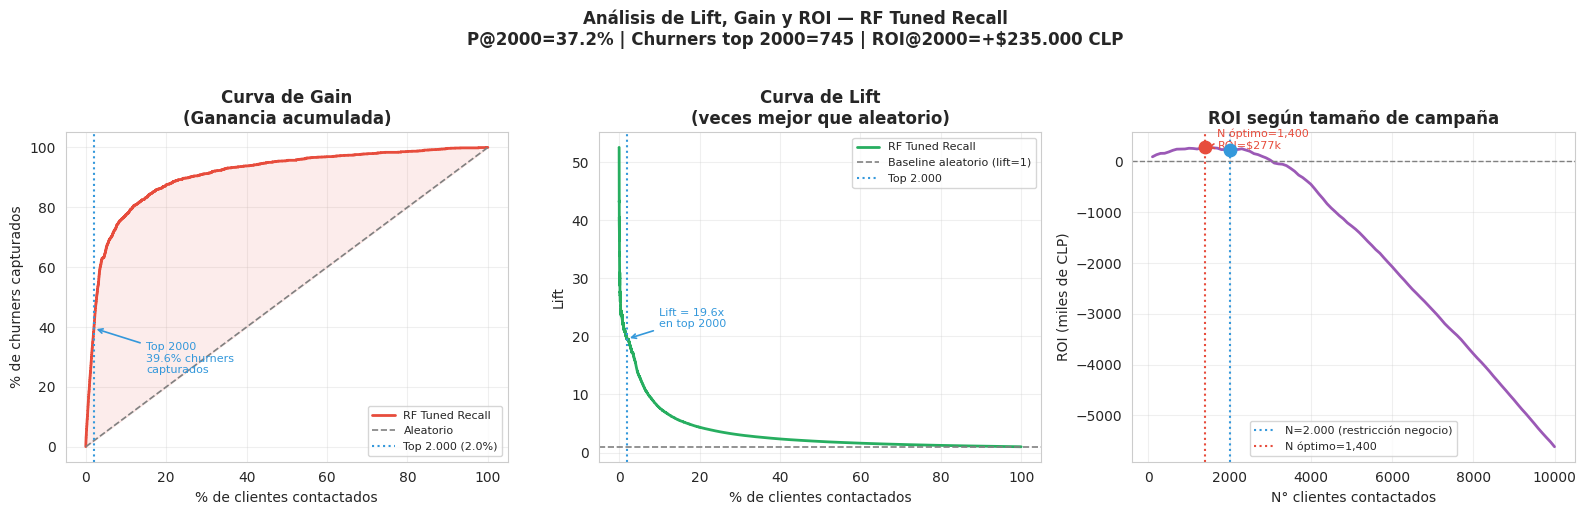


N óptimo por ROI (sin restricción): 1,400 clientes
ROI máximo posible               : $277,000 CLP
ROI con restricción de 2.000     : $235.000 CLP


In [ ]:
# ── Visualización ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: Curva de Gain ────────────────────────────────────────────────
axes[0].plot(df_lift['pct_clientes'], df_lift['gain'],
             color='#e74c3c', linewidth=2, label='RF Tuned Recall')
axes[0].plot([0, 100], [0, 100],
             '--', color='gray', linewidth=1.2, label='Aleatorio')
axes[0].axvline(2000/total_clientes*100,
                color='#3498db', linestyle=':', linewidth=1.5,
                label=f'Top 2.000 ({2000/total_clientes*100:.1f}%)')
axes[0].fill_between(
    df_lift['pct_clientes'],
    df_lift['gain'],
    df_lift['pct_clientes'],
    alpha=0.1, color='#e74c3c'
)
axes[0].set_xlabel('% de clientes contactados')
axes[0].set_ylabel('% de churners capturados')
axes[0].set_title('Curva de Gain\n(Ganancia acumulada)', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Anotar punto top 2000
gain_2000 = df_lift.iloc[1999]['gain']
axes[0].annotate(
    f'Top 2000\n{gain_2000:.1f}% churners\ncapturados',
    xy=(2000/total_clientes*100, gain_2000),
    xytext=(15, gain_2000 - 15),
    fontsize=8, color='#3498db',
    arrowprops=dict(arrowstyle='->', color='#3498db', lw=1.2)
)

# ── Panel 2: Curva de Lift ────────────────────────────────────────────────
axes[1].plot(df_lift['pct_clientes'], df_lift['lift'],
             color='#27ae60', linewidth=2, label='RF Tuned Recall')
axes[1].axhline(1, color='gray', linestyle='--',
                linewidth=1.2, label='Baseline aleatorio (lift=1)')
axes[1].axvline(2000/total_clientes*100,
                color='#3498db', linestyle=':', linewidth=1.5,
                label=f'Top 2.000')

lift_2000 = df_lift.iloc[1999]['lift']
axes[1].annotate(
    f'Lift = {lift_2000:.1f}x\nen top 2000',
    xy=(2000/total_clientes*100, lift_2000),
    xytext=(10, lift_2000 + 2),
    fontsize=8, color='#3498db',
    arrowprops=dict(arrowstyle='->', color='#3498db', lw=1.2)
)
axes[1].set_xlabel('% de clientes contactados')
axes[1].set_ylabel('Lift')
axes[1].set_title('Curva de Lift\n(veces mejor que aleatorio)',
                  fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# ── Panel 3: ROI según tamaño de campaña ──────────────────────────────────
tamanos  = list(range(100, min(10001, total_clientes+1), 100))
rois     = []
n_optimo = 2000
roi_max  = -999999

for n in tamanos:
    churners_n = df_lift.iloc[n-1]['churners_acum']
    roi_n      = (churners_n * 0.10 * 30_000) - (n * 1_000)
    rois.append(roi_n)
    if roi_n > roi_max:
        roi_max  = roi_n
        n_optimo = n

axes[2].plot(tamanos, [r/1000 for r in rois],
             color='#9b59b6', linewidth=2)
axes[2].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[2].axvline(2000, color='#3498db', linestyle=':',
                linewidth=1.5, label=f'N=2.000 (restricción negocio)')
axes[2].axvline(n_optimo, color='#e74c3c', linestyle=':',
                linewidth=1.5, label=f'N óptimo={n_optimo:,}')
axes[2].scatter([n_optimo], [roi_max/1000],
                color='#e74c3c', zorder=5, s=80)
axes[2].scatter([2000], [rois[tamanos.index(2000)]/1000],
                color='#3498db', zorder=5, s=80)

axes[2].annotate(
    f'N óptimo={n_optimo:,}\nROI=${roi_max/1000:.0f}k',
    xy=(n_optimo, roi_max/1000),
    xytext=(n_optimo + 300, roi_max/1000 - 20),
    fontsize=8, color='#e74c3c',
    arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2)
)
axes[2].set_xlabel('N° clientes contactados')
axes[2].set_ylabel('ROI (miles de CLP)')
axes[2].set_title('ROI según tamaño de campaña',
                  fontweight='bold')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle(
    f'Análisis de Lift, Gain y ROI — RF Tuned Recall\n'
    f'P@2000={0.3725:.1%} | Churners top 2000=745 | '
    f'ROI@2000=+$235.000 CLP',
    fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('lift_gain_roi_final.png', bbox_inches='tight')
plt.show()

print(f"\nN óptimo por ROI (sin restricción): {n_optimo:,} clientes")
print(f"ROI máximo posible               : ${roi_max:,.0f} CLP")
print(f"ROI con restricción de 2.000     : $235.000 CLP")

#### Conclusión del análisis de negocio

| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| P@2000 | 37.25% | 1 de cada 2.7 contactados es churner real |
| ROI campaña | +$235.000 CLP | Campaña rentable con 2.000 contactos |
| Lift top 2000 | 19.6x | 19.6 veces mejor que el azar |
| Gain top 2000 | 39.6% | Captura el 39.6% de todos los churners |
| N óptimo | 1.400 | ROI máximo sin restricción operativa |

**Interpretación**


1.   Recordemos que el ratio de P@2000 mínimo para que el contacto para la recuperación de clientes es de 33.33%. Esto debido a que si usamos la fórmula del ROI e igualamos a 0 esta indicador, la cantidad de churners mínimo es de 666.7 entre los 2000 a contactar nos da el 33.33%. La métrica actual del modelo es 37.25 lo que permite tener un margen de decaimiento de 4 puntos porcentuales.

2.   Con respecto al ROI aplicado a la restricción de 2000 contactos se tiene un total de 235000 CLP.

3.   Con respecto al Lift, el número de 19.6x mejor se debe a que estamos diviendo (para esos 2000mil) el totla de churn capturado con el modelo entre el total de churn si no hubiese modelo. si no hay modelo el ratio de churn seria 1882/98899 = 1.90% es decir que para los 2000 contactados se hubiesen tenido 38 churns. Con el modelo tenemos un total de 39.6% de churn capturado es decir 745 churns. Usando el modelo estamos siendo casi 20 veces mas eficiente para capturar a los churns que si no lo usasemos.

4.   Con respecto al Gain, estamos acumulando un total de 40% del churn capturado con el 2.02% de la población de agosto. Estos son los 2000 contactados que tenemos como restricción.

5.   Por último, el N óptimo responde a la pregunta de como maximizariamos el roi si no tuviesemos esa restricción. Recordemos que cada cliente adicional que contactamos nos cuesta 1000 clp y armamos nuestro ranking de mayor a menor probable de ser churn y esta densidad de churners va cayendo a medida que bajamos posiciones. Mientras mas bajamos en grupos de 500, menos churns encontramos y nos sigue costando 1000clp cada contacto. Esto genera una función convexa donde el punto máximo antes de que el roi empiece a disminuir es de 1400 contactos.




### 5. Feature importance

Top 30 features — RF Tuned Recall:
total_ic_mou           0.12
loc_ic_mou             0.10
recency_dias           0.09
offnet_mou             0.09
loc_ic_t2m_mou         0.07
Cluster_RFM            0.06
loc_ic_t2t_mou         0.06
onnet_mou              0.05
total_og_mou           0.05
loc_og_mou             0.04
loc_og_t2m_mou         0.04
total_rech_num         0.03
total_rech_amt         0.02
roam_ic_mou            0.02
arpu                   0.01
roam_og_mou            0.01
loc_og_t2t_mou         0.01
std_ic_t2m_mou         0.01
max_rech_amt           0.01
last_day_rch_amt       0.01
av_rech_amt_data       0.01
std_og_t2m_mou         0.01
loc_ic_t2f_mou         0.01
std_ic_mou             0.01
vol_2g_mb              0.01
max_rech_data          0.00
total_rech_data        0.00
vbc_efficiency_ratio   0.00
std_og_t2t_mou         0.00
vol_3g_mb              0.00

Features con importancia > 0.01 : 20
Features con importancia > 0.001: 41
Features con importancia = 0    : 15


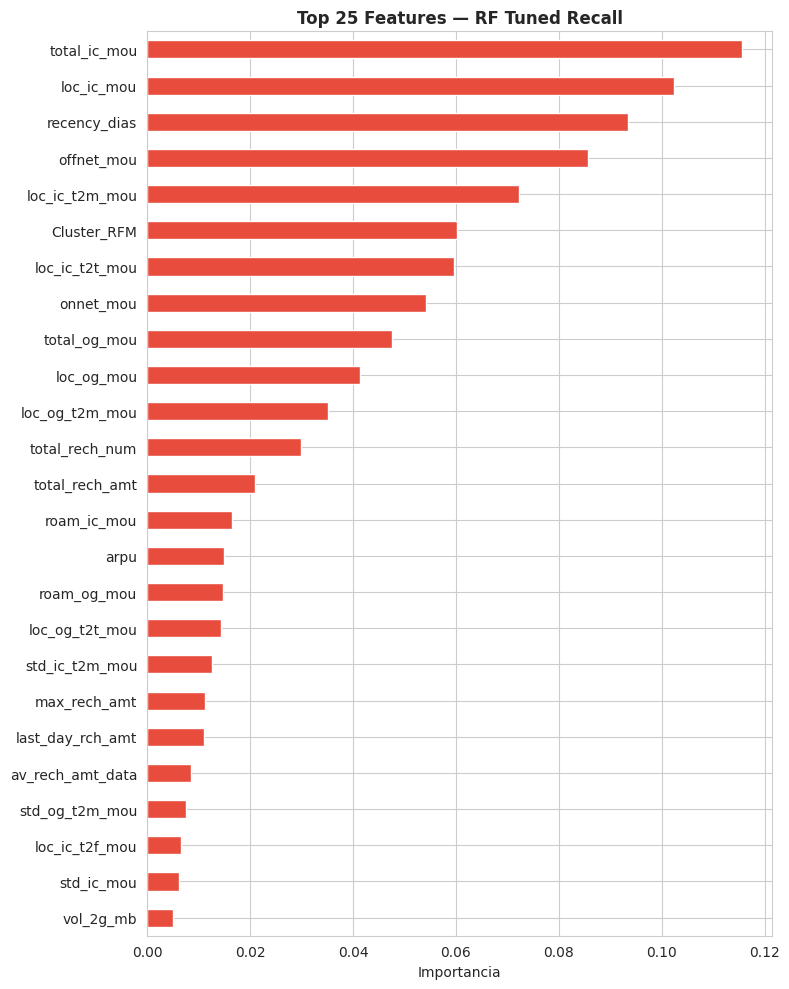

In [ ]:
# ── Feature Importance del modelo ganador ─────────────────────────────────
importancias_ganador = pd.Series(
    modelo_ganador.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 30 features — RF Tuned Recall:")
print(importancias_ganador.head(30).to_string())
print()
print(f"Features con importancia > 0.01 : {(importancias_ganador > 0.01).sum()}")
print(f"Features con importancia > 0.001: {(importancias_ganador > 0.001).sum()}")
print(f"Features con importancia = 0    : {(importancias_ganador == 0).sum()}")

# Visualización
fig, ax = plt.subplots(figsize=(8, 10))
importancias_ganador.head(25).sort_values().plot(
    kind='barh', ax=ax, color='#e74c3c'
)
ax.set_title('Top 25 Features — RF Tuned Recall', fontweight='bold')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

### 5. Feature Importance

Se analizó la importancia de cada variable en el modelo
final (RF Tuned Recall) para entender qué comportamientos
del cliente son los más predictivos de churn.


##### Hallazgos principales

Las variables más importantes confirman los patrones
encontrados en el EDA:

| # | Variable | Importancia | Interpretación |
|---|----------|-------------|----------------|
| 1 | total_ic_mou | 0.12 | Minutos entrantes totales |
| 2 | loc_ic_mou | 0.10 | Minutos locales entrantes |
| 3 | recency_dias | 0.09 | Días sin recargar |
| 4 | offnet_mou | 0.09 | Minutos fuera de la red |
| 5 | loc_ic_t2m_mou | 0.07 | Minutos locales entrantes otra red |
| 6 | Cluster_RFM | 0.06 | Segmento de comportamiento |
| 7 | loc_ic_t2t_mou | 0.06 | Minutos locales entrantes misma red |
| 8 | onnet_mou | 0.05 | Minutos dentro de la red |
| 9 | total_og_mou | 0.05 | Minutos salientes totales |
| 10 | arpu | 0.01 | Revenue del cliente |


##### Conclusión

El modelo confirma el hallazgo central del EDA:
**la inactividad en minutos y recarga es la señal más fuerte de churn**.

Las 4 variables más importantes son todas de minutos
de llamadas (total_ic_mou, loc_ic_mou, offnet_mou, onnet_mou),
seguidas por recency_dias (días sin recargar) y Cluster_RFM
(segmento de comportamiento construido en el EDA).

Esto es consistente con lo encontrado en el análisis
exploratorio: la mediana de minutos para churners es 0,
mientras que para no-churners supera los 100 minutos.

#### Prueba de reducción de variables

Se realizó una prueba adicional seleccionando solo
las variables con importancia > 0.001 (41 variables
de las 68 originales) para evaluar si un modelo
más simple mejoraba el P@2000.

In [ ]:
# ── Entrenar con top features + mejores params ────────────────────────────
# Seleccionar features con importancia > umbral
UMBRAL = 0.001

top_features = importancias_ganador[
    importancias_ganador > UMBRAL
].index.tolist()

print(f"Features seleccionadas (> {UMBRAL}): {len(top_features)}")
print(top_features)

# Preparar datos solo con top features
rus = RandomUnderSampler(sampling_strategy=0.10, random_state=42)
X_r_top, y_r_top = rus.fit_resample(
    X_train[top_features], y_train
)

# Entrenar con los mejores params del tuning de recall
rf_top = RandomForestClassifier(
    **search_recall.best_params_,
    n_jobs=-1,
    random_state=42
)
rf_top.fit(X_r_top, y_r_top)
prob_top = rf_top.predict_proba(X_test[top_features])[:, 1]

# ── Comparación ───────────────────────────────────────────────────────────
modelos_comp = {
    'Baseline RF'      : (prob_rf,      X_test),
    'Tuned Recall'     : (prob_ganador,  X_test),
    'Top Features+Params': (prob_top,   X_test[top_features]),
}

print("\n" + "═"*75)
print("  COMPARACIÓN FINAL")
print("═"*75)
print(f"{'Modelo':<22} {'AUC':>7} {'F1':>7} {'Recall':>8} "
      f"{'P@2000':>8} {'Churners':>10} {'ROI':>12}")
print("─"*75)

for nombre, (probs, _) in modelos_comp.items():
    auc  = roc_auc_score(y_test, probs)
    pred = (probs >= 0.5).astype(int)
    f1   = f1_score(y_test, pred)
    rec  = recall_score(y_test, pred)

    df_r = pd.DataFrame({
        'churn_real': y_test.values,
        'churn_prob': probs
    }).sort_values('churn_prob', ascending=False).reset_index(drop=True)

    p2000     = df_r.head(2000)['churn_real'].mean()
    churn_top = df_r.head(2000)['churn_real'].sum()
    roi       = (churn_top * 0.10 * 30_000) - (2000 * 1_000)

    print(f"{nombre:<22} {auc:>7.4f} {f1:>7.4f} {rec:>8.4f} "
          f"{p2000:>8.4f} {churn_top:>10.0f} ${roi:>10,.0f}")

Features seleccionadas (> 0.001): 41
['total_ic_mou', 'loc_ic_mou', 'recency_dias', 'offnet_mou', 'loc_ic_t2m_mou', 'Cluster_RFM', 'loc_ic_t2t_mou', 'onnet_mou', 'total_og_mou', 'loc_og_mou', 'loc_og_t2m_mou', 'total_rech_num', 'total_rech_amt', 'roam_ic_mou', 'arpu', 'roam_og_mou', 'loc_og_t2t_mou', 'std_ic_t2m_mou', 'max_rech_amt', 'last_day_rch_amt', 'av_rech_amt_data', 'std_og_t2m_mou', 'loc_ic_t2f_mou', 'std_ic_mou', 'vol_2g_mb', 'max_rech_data', 'total_rech_data', 'vbc_efficiency_ratio', 'std_og_t2t_mou', 'vol_3g_mb', 'std_og_mou', 'loc_og_t2f_mou', 'std_ic_t2t_mou', 'spl_og_mou', 'ic_others', 'fb_user_1', 'loc_og_t2c_mou', 'std_ic_t2f_mou', 'monthly_2g_1', 'arpu_2g', 'count_rech_2g']

═══════════════════════════════════════════════════════════════════════════
  COMPARACIÓN FINAL
═══════════════════════════════════════════════════════════════════════════
Modelo                     AUC      F1   Recall   P@2000   Churners          ROI
──────────────────────────────────────────────

| Modelo | P@2000 | Churners | ROI |
|--------|--------|----------|-----|
| Todas las variables | 37.25% | 745 | +$235.000 |
| Top 41 variables | 36.65% | 733 | +$199.000 |

**Conclusión:** reducir las variables empeoró levemente
el P@2000 (-0.6 puntos) y el ROI (-$36.000).
Las variables con baja importancia individual
aportan señal marginal que en conjunto beneficia
al modelo. Se decidió mantener todas las variables
en el modelo final.

### 6. Mejora del modelo

#### ¿Qué harías para mejorar la performance?

**1. Incorporar un mes adicional de historia (Mayo)**

Con 3 meses de historia disponibles (May, Jun, Jul)
se podría calcular la aceleración de la caída de ARPU:
delta_jun = arpu_jun - arpu_may  → tendencia mes 1
delta_jul = arpu_jul - arpu_jun  → tendencia mes 2
Un cliente cuyo ARPU cae 20% en Junio y 50% en Julio
es más riesgoso que uno que cae 35% en ambos meses,
aunque el nivel final sea el mismo.
Esta señal no es capturable con solo 2 meses de historia y que se pudo capturar en el EDA.

**2. Optimizar directamente por P@2000**
Reemplazar el recall o f1 score por una metrica custom dentro del fine tunning.

**3. Probar otros modelos**
Probar mas modelos para el desbalanceo como naives bayes, light gbm que suelen ser muy útiles en estos casos.

**4. Enfoque comercial**
Solo contactaría a los 1.400 clientes óptimos
(N óptimo identificado en el análisis de ROI)
o priorizaría en base a un corte de probabilidad.

Para los clientes con probabilidad media
aplicaría campañas de retención usando medios
propios de menor costo (email, SMS, push notifications)
e iría midiendo su efectividad versus el contacto
directo por llamada ($1.000 CLP por cliente).

Esto permitiría ampliar el alcance de la campaña
sin incrementar proporcionalmente el costo,
mejorando el ROI total de la estrategia de retención.

#### ¿Qué información adicional te gustaría tener?

1.  Más meses de historia (mínimo 4-6) para capturar estacionalidades y armas mas variables de comportamiento.
2.  Encuesta de clientes sobre el último servicio brindado por la empresa.
3.  Reclamos hecho por el cliente.
4.  Tiempo de permanencia como cliente.
5.  Tipos de planes que contratan y su priorización de estos planes.
6.  Cantidad de líneas por cliente disponible.

#### ¿Qué simplificarías para producción en el corto plazo?

1.   Reducir las variables del modelo si el impacto mostrado no es significativo. Al ser mas sencillo es mas rápido de ejecutar y de mantener.
2. Definir grupos de propensión (Alto, Medio, Bajo)
   en base al score del modelo para orientar
   al equipo de retención sobre la intensidad
   del contacto y el tipo de incentivo a ofrecer:
   - Alto  (prob > umbral top 1.400) → contacto directo
   - Medio (prob media)              → medios propios
   - Bajo  (prob baja)               → sin acción
3. Reentrenamiento disparado por dos criterios:
   - **Automático:** cuando P@2000 caiga por debajo
     del 33.33% (umbral de break-even)
   - **Periódico:** trimestral con los últimos
     3-6 meses de datos disponibles
   Monitorear mensualmente las curvas de Lift y Gain
   para detectar degradación temprana del modelo.

#### **Adicional**
**Variables delta descartadas del modelo final**

Se construyeron variables de cambio entre meses
(delta_arpu, delta_total_og_mou, delta_total_rech_amt, etc.)
calculadas como la variación porcentual de Julio vs Junio.

Al incorporarlas al modelo se observó
una degradación en las métricas:

| Escenario | AUC | F1 | P@2000 |
|-----------|-----|----|--------|
| Jun+Jul Sin deltas | 0.931 | 0.394 | ~35% |
| Jun+Jul Con deltas | 0.903 | 0.221 | ~27% |

**Causa identificada:** las filas de Junio (99.999 registros)
tienen delta=NaN porque no existe mes anterior.
Al imputar con 0 se introduce ruido: el modelo interpreta
"sin cambio" cuando en realidad "no hay información".
Esto confunde al modelo y deteriora el ranking del top 2.000.

**Conclusión:** los deltas son valiosas conceptualmente
y confirman el hallazgo del EDA (caída de ARPU de -62.75%
en churners). Sin embargo, con solo 2 meses de historia
no es posible aprovecharlos sin introducir ruido.
Con Mayo disponible, los deltas podrían calcularse
sin NaN para todos los clientes, potencialmente
mejorando el modelo en 3-5 puntos de P@2000.

**Se finalizó la parte del archivo 02_Modelado.ipynb la cual cubre "Segunda parte: Modelo predictivo"**